In [11]:
import sys
!{sys.executable} --version

# as of 02/02/2024 the clarabel solver is one of the few solvers to import and execute without error
# do not use proxqp or  osqp in Python 3.11.5

# !pip install qpsolvers[open_source_solvers]
# !pip install quadprog
# !pip install qpsolvers[clarabel,daqp,proxqp,scs] 

import math
import numpy as np
from datetime import datetime
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from IPython.display import display
from math import log
from qpsolvers import solve_qp

%matplotlib inline


Python 3.14.2


In [12]:
import warnings
warnings.filterwarnings("ignore")

# https://en.wikipedia.org/wiki/Dow_Jones_Industrial_Average

companies, tickers = ['Honeywell','Salesforce','Meta','Apple','Google'],['HON','CRM','META','AAPL','GOOGL']

tickers_df = yf.download(tickers, 
                      start='2020-01-01', 
                      end='2026-02-01', 
                      progress=False, auto_adjust=True)
display(tickers_df.head())
display(tickers_df.tail())

# returns = tickers_df['Close'].applymap(log).diff()[1:]
returns = tickers_df['Close'].map(log).diff()[1:]

# annualize returns and covariance

stats = returns.agg(['mean', 'std', 'var'])
annual_returns = stats.transpose()['mean'] * 252
annual_covar = returns.cov() * 252
display(stats)
display(annual_covar)
print(annual_returns)

Price           Close                                                 \
Ticker           AAPL         CRM      GOOGL         HON        META   
Date                                                                   
2020-01-02  72.400536  164.985397  67.920807  150.366959  208.324768   
2020-01-03  71.696617  164.175232  67.565491  148.761765  207.222504   
2020-01-06  72.267944  171.367828  69.366386  147.638947  211.125214   
2020-01-07  71.928070  173.887207  69.232399  147.722092  211.582031   
2020-01-08  73.085106  175.201279  69.725174  147.846878  213.727066   

Price            High                                                 ...  \
Ticker           AAPL         CRM      GOOGL         HON        META  ...   
Date                                                                  ...   
2020-01-02  72.460799  165.064439  67.920807  150.375267  208.334693  ...   
2020-01-03  72.455935  164.768035  68.172409  149.568533  208.940499  ...   
2020-01-06  72.306514  171.585189  69.391693  148.362541  211.303958  ...   
2020-01-07  72.533110  174.746758  69.648755  148.104679  213.091491  ...   
2020-01-08  73.386423  176.703036  70.063120  148.961381  214.739995  ...   

Price            Open                                                 \
Ticker           AAPL         CRM      GOOGL         HON        META   
Date                                                                   
2020-01-02  71.409800  161.952243  66.914911  147.630584  205.315788   
2020-01-03  71.629122  163.078556  66.894565  148.329275  205.772640   
2020-01-06  70.819216  163.019269  67.074696  147.913422  205.266132   
2020-01-07  72.277594  171.150455  69.497895  147.522483  211.343706   
2020-01-08  71.631552  173.126482  69.218004  147.772025  211.522464   

Price          Volume                                        
Ticker           AAPL      CRM     GOOGL      HON      META  
Date                                                         
2020-01-02  135480400  5189300  27278000  3031701  12077100  
2020-01-03  146322800  3205400  23408000  2976317  11188400  
2020-01-06  118387200  8836200  46768000  3477852  17058900  
2020-01-07  108872000  8272700  34330000  3185971  14912400  
2020-01-08  132079200  7225100  35314000  2700776  13475000  

[5 rows x 25 columns]

Price            Close                                                  \
Ticker            AAPL         CRM       GOOGL         HON        META   
Date                                                                     
2026-01-26  255.171234  229.399994  333.260010  221.160004  672.359985   
2026-01-27  258.028534  228.529999  334.549988  220.910004  672.969971   
2026-01-28  256.200287  227.960007  336.010010  216.639999  668.729980   
2026-01-29  258.038544  214.080002  338.250000  227.240005  738.309998   
2026-01-30  259.237427  212.289993  338.000000  227.520004  716.500000   

Price             High                                                  ...  \
Ticker            AAPL         CRM       GOOGL         HON        META  ...   
Date                                                                    ...   
2026-01-26  256.320153  230.949997  335.839996  221.830002  675.280029  ...   
2026-01-27  261.705117  235.740005  337.910004  222.779999  676.820007  ...   
2026-01-28  258.618008  231.860001  337.540009  221.270004  677.679993  ...   
2026-01-29  259.407258  217.279999  342.290009  227.860001  744.000000  ...   
2026-01-30  261.655147  215.550003  340.000000  229.589996  732.169983  ...   

Price             Open                                                  \
Ticker            AAPL         CRM       GOOGL         HON        META   
Date                                                                     
2026-01-26  251.244900  229.429993  327.809998  221.360001  665.130005   
2026-01-27  258.927717  231.940002  335.369995  221.330002  674.590027   
2026-01-28  257.409147  229.389999  336.059998  220.009995  674.500000   
2026-01-29  257.758807  216.669998  340.299988  221.240005  737.429993   
2026-01-30  254.931443  214.160004  340.000000  226.740005  727.500000   

Price         Volume                                         
Ticker          AAPL       CRM     GOOGL      HON      META  
Date                                                         
2026-01-26  55969200   7239600  26042100  3703900  16327400  
2026-01-27  49648300   9838400  21636200  3520800  13297400  
2026-01-28  41288000   8465900  27434400  5107500  25709600  
2026-01-29  67253000  18555600  39785600  6945200  59852900  
2026-01-30  92443400  11090400  31024000  6719200  23744600  

[5 rows x 25 columns]

Ticker,AAPL,CRM,GOOGL,HON,META
mean,0.000835,0.000165,0.001051,0.000271,0.000809
std,0.019916,0.024470,0.020361,0.016893,0.027879
var,0.000397,0.000599,0.000415,0.000285,0.000777


Ticker,AAPL,CRM,GOOGL,HON,META
Ticker,,,,,
AAPL,0.099958,0.063921,0.063873,0.040202,0.076136
CRM,0.063921,0.150895,0.065066,0.036913,0.085201
GOOGL,0.063873,0.065066,0.104473,0.036321,0.086228
HON,0.040202,0.036913,0.036321,0.071911,0.043280
META,0.076136,0.085201,0.086228,0.043280,0.195865


Ticker
AAPL     0.210500
CRM      0.041603
GOOGL    0.264823
HON      0.068349
META     0.203858
Name: mean, dtype: float64


# Computing the Efficient Frontier
## If w is the weight vector of stocks with expected returns μ, then the portfolio return is equal to each stock’s weight multiplied by its return, i.e wTμ. The portfolio risk in terms of the covariance matrix Σ is given by wTΣw. Portfolio optimisation can then be regarded as a convex optimisation problem, and a solution can be found using quadratic programming. If we denote the target return as μ∗, the precise statement of the long-only portfolio optimisation problem is as follows:

## min_w : $w^T\Sigma w$

## subject to 

## $$w^T \mu = \mu^*$$

## $$w^T \textbf{1} = 1$$

## $$w_i \geq 0$$

# Calculate the efficient frontier
## select a range of target return values ($r^*$)
## call the optimizer to find the portfolio with the minimum volatility for each $r^*$ value

# Quadratic optimizer
## https://pypi.org/project/qpsolvers/

minimize     $\frac{1}{2} x^T P x + q^T x$

subject to $$G x <= h $$
$$A x = b$$
$$lb <= x <= ub$$

# Mapping variables in the quadratic optimizer

$$P = \Sigma$$

\begin{equation*}
q = \begin{bmatrix}
0 \\
0 \\
0
\end{bmatrix}
\end{equation*}

$$G, h = None, None$$

\begin{equation*}
A =  \begin{bmatrix}
r_0 & r_1 & r_2 \\
1 & 1 & 1
\end{bmatrix}
\begin{bmatrix}
w_0 \\
w_1 \\
w_2  
\end{bmatrix}=
\begin{bmatrix}
r^* \\
1 
\end{bmatrix}=b
\end{equation*}

\begin{equation*}
lb = \begin{bmatrix}
0 \\
0 \\
0
\end{bmatrix}<=
\begin{bmatrix}
w_0 \\
w_1 \\
w_2  
\end{bmatrix}<=
\begin{bmatrix}
1 \\
1 \\
1
\end{bmatrix}=ub
\end{equation*}

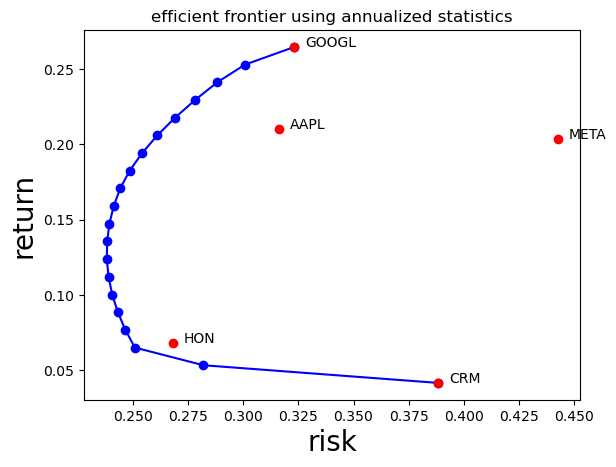

In [21]:
from numpy import array, dot
from qpsolvers import solve_qp

class create_efficient_frontier():
    def __init__(self, returns, covar):
        self.returns = np.array(returns)
        self.covar = np.array(covar)
        self.n =len(self.covar)
        self.tickers = list(returns.index)

    def get_portfolio(self, return_target):
        """for a given target return create lowest variance long-only portfolio"""
        P, q = self.covar, np.array([0.] * self.n)
        G, h = None,None 
        A = np.array([annual_returns, np.array([1.0] * self.n)])
        b = np.array([return_target, 1.0])
        lb, ub = np.array([0.] * self.n),np.array([1.] * self.n)

        self.portfolio = solve_qp(P, q, G, h, A, b, lb, ub, solver='clarabel')  # specified 02/02/2024 'osqp')  # specify solver 02/02/2023
        return {"portfolio":self.portfolio, "risk_ret":self.risk_return()}  # return (allocation , risk-return)

    def risk_return(self):
        """return the risk and return for this portfolio"""
        return np.sqrt(self.portfolio.dot(self.covar.dot(self.portfolio))),\
            self.returns.dot(self.portfolio)

# loop through range of returns to create 20 portfolios on the efficient frontier
    
ef = create_efficient_frontier(annual_returns, annual_covar)
min_return, max_return = min(annual_returns), max(annual_returns)
frontier = np.array([ef.get_portfolio(r)['risk_ret'] 
                     for r in np.linspace(min_return, max_return, 20)]).T

# plot the efficient frontier in the Markowitz risk-return space

plt.plot(frontier[0], frontier[1], 'o-', color='blue') # plot the efficient frontier
for n, r, s in zip(annual_returns.index, annual_returns, np.sqrt(np.diag(annual_covar))):
    plt.plot([s], [r], 'o', color='red')
    plt.text(s+0.005, r, n)
plt.title('efficient frontier using annualized statistics')
plt.xlabel('risk', fontsize=20)
plt.ylabel('return', fontsize=20)
plt.show()

In [14]:
print(annual_returns, annual_covar)

Ticker
AAPL     0.210500
CRM      0.041603
GOOGL    0.264823
HON      0.068349
META     0.203858
Name: mean, dtype: float64 Ticker      AAPL       CRM     GOOGL       HON      META
Ticker                                                  
AAPL    0.099958  0.063921  0.063873  0.040202  0.076136
CRM     0.063921  0.150895  0.065066  0.036913  0.085201
GOOGL   0.063873  0.065066  0.104473  0.036321  0.086228
HON     0.040202  0.036913  0.036321  0.071911  0.043280
META    0.076136  0.085201  0.086228  0.043280  0.195865


# Portfolios on the efficient frontier

In [15]:
frontier_pf = pd.DataFrame(np.array([ef.get_portfolio(r)['portfolio'] 
                     for r in np.linspace(min_return, max_return, 20)]),
                           columns=ef.tickers)
display(frontier_pf[-4:])
frontier.T[-4:]

,AAPL,CRM,GOOGL,HON,META
16,3.152778e-01,1.673510e-09,0.592505,9.221722e-02,2.886944e-08
17,3.310162e-01,1.549434e-09,0.640914,2.806964e-02,2.937831e-08
18,2.162686e-01,5.391431e-09,0.783731,4.103527e-08,1.240484e-07
19,7.050049e-11,-7.112018e-11,1.000000,8.914895e-11,-8.971599e-11


array([[0.27819785, 0.22957809],
       [0.2882348 , 0.24132652],
       [0.30082987, 0.25307494],
       [0.32322245, 0.26482336]])

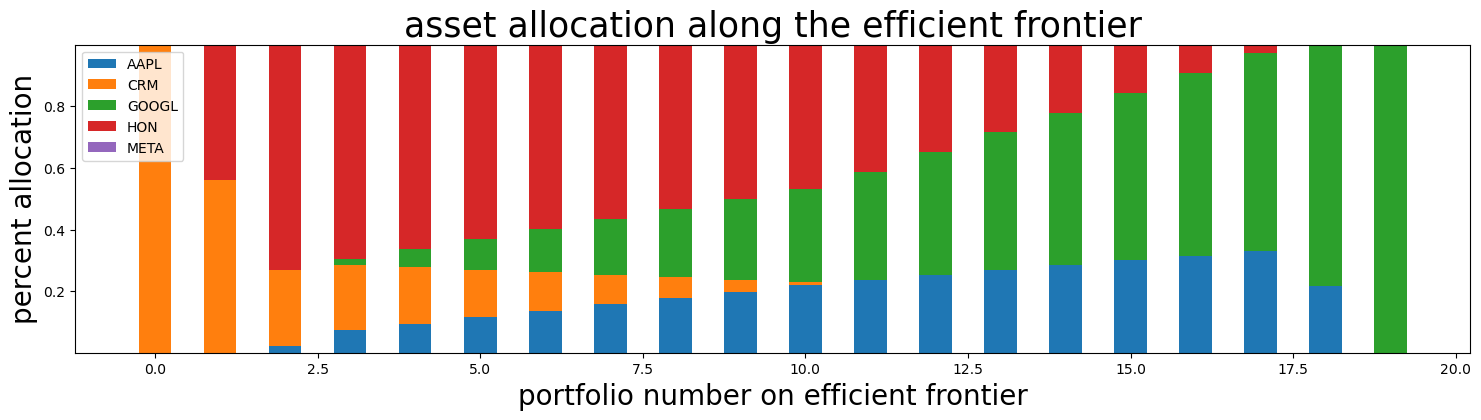

In [16]:
# create stacked bar plot showing security allocations for portfolios on the efficient frontier 

plt.figure(figsize=(18,4))
ind, width = range(len(frontier_pf)), .5  # number of portfolios, the width of each bar in the plot

# loop through portfolios on the efficient frontier

cumulative = [0.] * frontier_pf.shape[0]
for t in frontier_pf.columns:
    plt.bar(ind, frontier_pf[t], width, bottom=cumulative, label=t)
    cumulative += frontier_pf[t]
    
plt.legend(loc='upper left')
plt.title("asset allocation along the efficient frontier", fontsize=25)
plt.ylabel("percent allocation", fontsize=20)
plt.xlabel("portfolio number on efficient frontier", fontsize=20)
plt.show()

# locate the min variance portfolio on the efficient frontier

In [17]:
frontier1 = np.array([ef.get_portfolio(r) for r in np.linspace(min_return, max_return, 20)]).T
frontier1_portfolio = pd.DataFrame([p['portfolio'] for p in frontier1], columns=ef.tickers)
frontier1_rr = pd.DataFrame([p['risk_ret'] for p in frontier1], columns=['risk','return'])

minVar = [i for i,r in enumerate(frontier1_rr['risk']) if r == frontier1_rr['risk'].min()]

print('minimum variance portfolio')
display(frontier1_rr.iloc[minVar, :])
display(frontier1_portfolio.iloc[minVar, :])

minimum variance portfolio


,risk,return
7,0.238176,0.123842


,AAPL,CRM,GOOGL,HON,META
7,0.15686,0.096345,0.182072,0.564722,8.049702e-08


In [25]:
# count the number of portfolios that are abovfrontier.shape[1], minVar[0]

(20, 7)

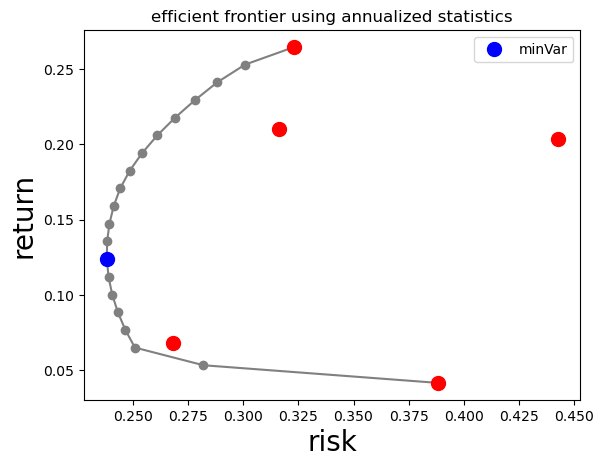

In [18]:
# plot the efficient frontier 

plt.plot(frontier[0], frontier[1], 'o-', color='gray') # plot the efficient frontier
for r, s in zip(annual_returns, np.sqrt(np.diag(annual_covar))):
    plt.plot([s], [r], 'o', color='red', markersize=10) 

# identify the minimum variance portfolio on the plot

mV = frontier1_rr.iloc[minVar, :].values[0]
plt.plot(mV[0],mV[1], 'o', color='blue', markersize=10, label='minVar')

plt.title('efficient frontier using annualized statistics')
plt.xlabel('risk', fontsize=20)
plt.ylabel('return', fontsize=20)
plt.legend()
plt.show()

# Component beta
## composition and risk-return for minimum variance portfolio

# compute beta for a stock
## regress its returns on the portfolio (in this case min var) returns

In [19]:
mv_pf = frontier1_portfolio.iloc[minVar, :]
# pf = np.array(mv_pf)  
portfolio_returns = np.array(returns).dot(np.array(mv_pf).T)

display(mv_pf)
display(frontier1_rr.iloc[minVar, :])

np.std(portfolio_returns) * np.sqrt(252), np.mean(portfolio_returns) * 252

,AAPL,CRM,GOOGL,HON,META
7,0.15686,0.096345,0.182072,0.564722,8.049702e-08


,risk,return
7,0.238176,0.123842


(np.float64(0.23809843064344466), np.float64(0.12384227860722127))

In [20]:
# https://scipy-lectures.org/packages/statistics/auto_examples/plot_regression.html

from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm

# add column for minimum variance portfolio returns

returns_p = returns.copy()
returns_p['portfolio'] = portfolio_returns
display(returns_p[:5])

# regress the returns for CRM (Salesforce) on the returns for the minimum variance portfolio

selected_ticker = ['CRM','HON','META'][0]

model = ols(f"{selected_ticker} ~ portfolio", returns_p).fit()   # regrssion of returns

print(model.summary())
anova_results = anova_lm(model)

print('\nANOVA results')
print(anova_results)

f"{selected_ticker} beta = {model.params.loc['portfolio']:0.4f}"

Ticker,AAPL,CRM,GOOGL,HON,META,portfolio
Date,,,,,,
2020-01-03,-0.009770,-0.004923,-0.005245,-0.010733,-0.005305,-0.009023
2020-01-06,0.007937,0.042878,0.026305,-0.007576,0.018658,0.005887
2020-01-07,-0.004714,0.014595,-0.001933,0.000563,0.002161,0.000633
2020-01-08,0.015958,0.007529,0.007092,0.000844,0.010087,0.004997
2020-01-09,0.021019,0.012720,0.010443,0.007342,0.014209,0.010570


                            OLS Regression Results                            
Dep. Variable:                    CRM   R-squared:                       0.383
Model:                            OLS   Adj. R-squared:                  0.383
Method:                 Least Squares   F-statistic:                     946.6
Date:                Fri, 13 Feb 2026   Prob (F-statistic):          4.13e-162
Time:                        08:07:40   Log-Likelihood:                 3868.1
No. Observations:                1527   AIC:                            -7732.
Df Residuals:                    1525   BIC:                            -7721.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0003      0.000     -0.672      0.5

'CRM beta = 1.0093'